# Non-Stationary Experiments

In [40]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from matplotlib.axes import Axes
from scipy.stats import binomtest

## Data

In [41]:
regs_in = ["B", "C", "D", "E", "F", "G", "H", "I", "J"]
regs_out = ["C", "D", "F", "G", "H", "I"]

progressive_labels = ["Original (retrained)", "Original (fine-tuned)", "Progressive (retrained)"]
progressive_in = np.array([
    [0.523, 0.49, 0.406, 0.515, 0.464, 0.508, 0.531, 0.527, 0.462],
    [0.436, 0.457, 0.462, 0.514, 0.446, 0.509, 0.512, 0.503, 0.471],
    [0.417, 0.437, 0.408, 0.435, 0.453, 0.489, 0.48, 0.497, 0.429]
])
progressive_out = np.array([
    [0.516, 0.529, 0.557, 0.557, 0.528, 0.502],
    [0.528, 0.51, 0.509, 0.568, 0.476, 0.503],
    [0.472, 0.517, 0.511, 0.499, 0.511, 0.521]
])

tuned_labels = ["Original (retrained)", "Original (fine-tuned)", "Tuned (retrained)"]
tuned_in = np.array([
    [0.533, 0.537, 0.498, 0.54, 0.558, 0.507, 0.566, 0.527, 0.538],
    [0.51, 0.505, 0.513, 0.532, 0.506, 0.558, 0.569, 0.529, 0.538],
    [0.527, 0.507, 0.506, 0.518, 0.545, 0.504, 0.507, 0.509, 0.511]
])
tuned_out = np.array([
    [0.52, 0.562, 0.558, 0.561, 0.567, 0.519],
    [0.498, 0.538, 0.57, 0.56, 0.543, 0.548],
    [0.503, 0.518, 0.511, 0.492, 0.531, 0.481]
])

combined_labels = ["Original (retrained)", "Original (fine-tuned)", "Progressive (retrained)", "Tuned (retrained)"]
combined_in = np.array([
    [0.491, 0.502, 0.488, 0.473, 0.487, 0.527, 0.474, 0.535, 0.491],
    [0.459, 0.439, 0.488, 0.448, 0.418, 0.472, 0.49, 0.534, 0.526],
    [0.466, 0.449, 0.437, 0.446, 0.454, 0.484, 0.441, 0.459, 0.44],
    [0.493, 0.466, 0.459, 0.406, 0.44, 0.48, 0.447, 0.463, 0.458]
])
combined_out = np.array([
    [0.518, 0.543, 0.535, 0.559, 0.545, 0.573],
    [0.513, 0.519, 0.524, 0.55, 0.511, 0.539],
    [0.437, 0.471, 0.499, 0.519, 0.493, 0.528],
    [0.483, 0.482, 0.49, 0.539, 0.49, 0.516]
])

playoff_labels = ["Progressive", "Tuned", "Combined"]
playoff_in = np.array([
    [
        [np.nan, 0.448, 0.509],
        [0.552, np.nan, 0.518],
        [0.491, 0.482, np.nan]
    ],
    [
        [np.nan, 0.416, 0.475],
        [0.584, np.nan, 0.537],
        [0.525, 0.463, np.nan]
    ],
    [
        [np.nan, 0.423, 0.456],
        [0.577, np.nan, 0.56],
        [0.544, 0.44, np.nan]
    ],
    [
        [np.nan, 0.449, 0.525],
        [0.551, np.nan, 0.567],
        [0.475, 0.433, np.nan]
    ],
    [
        [np.nan, 0.413, 0.476],
        [0.587, np.nan, 0.59],
        [0.524, 0.41, np.nan]
    ],
    [
        [np.nan, 0.485, 0.459],
        [0.515, np.nan, 0.516],
        [0.541, 0.484, np.nan]
    ],
    [
        [np.nan, 0.416, 0.484],
        [0.584, np.nan, 0.564],
        [0.516, 0.436, np.nan]
    ],
    [
        [np.nan, 0.498, 0.498],
        [0.502, np.nan, 0.49],
        [0.502, 0.51, np.nan]
    ],
    [
        [np.nan, 0.448, 0.461],
        [0.552, np.nan, 0.505],
        [0.539, 0.495, np.nan]
    ],
])
playoff_out = np.array([
    [
        [np.nan, 0.492, 0.492],
        [0.508, np.nan, 0.48],
        [0.508, 0.52, np.nan]
    ],
    [
        [np.nan, 0.486, 0.495],
        [0.514, np.nan, 0.5],
        [0.505, 0.5, np.nan]
    ],
    [
        [np.nan, 0.475, 0.488],
        [0.525, np.nan, 0.523],
        [0.512, 0.477, np.nan]
    ],
    [
        [np.nan, 0.497, 0.459],
        [0.503, np.nan, 0.478],
        [0.541, 0.522, np.nan]
    ],
    [
        [np.nan, 0.405, 0.496],
        [0.595, np.nan, 0.601],
        [0.504, 0.399, np.nan]
    ],
    [
        [np.nan, 0.511, 0.512],
        [0.489, np.nan, 0.516],
        [0.488, 0.484, np.nan]
    ],
])

## Plotting

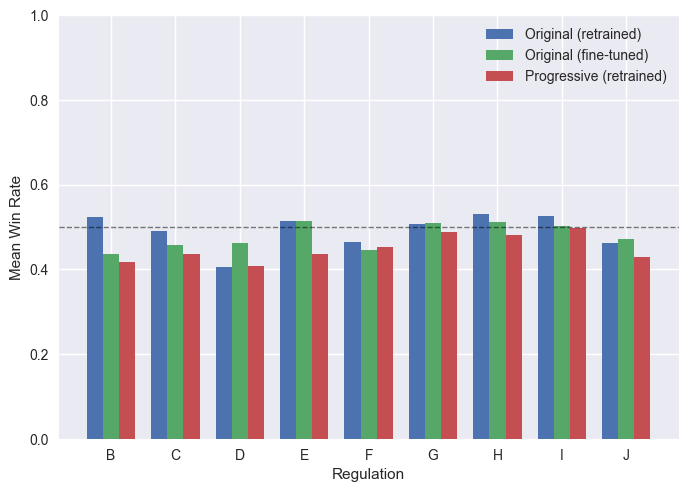

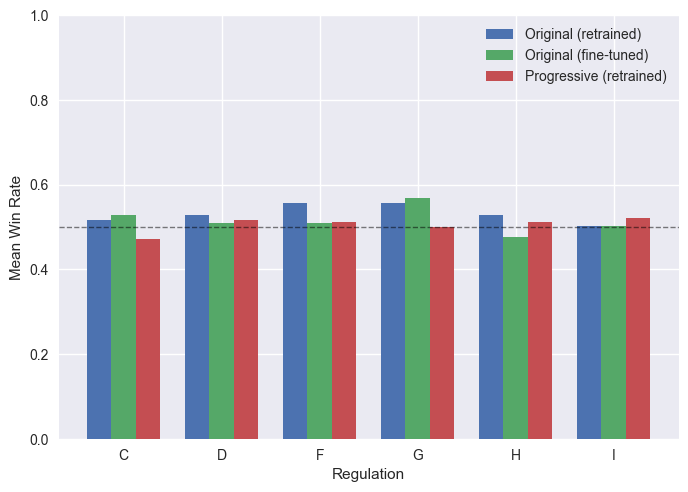

C:\Users\Thoma\AppData\Local\Temp\ipykernel_5184\1295145815.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(pad=2.5)


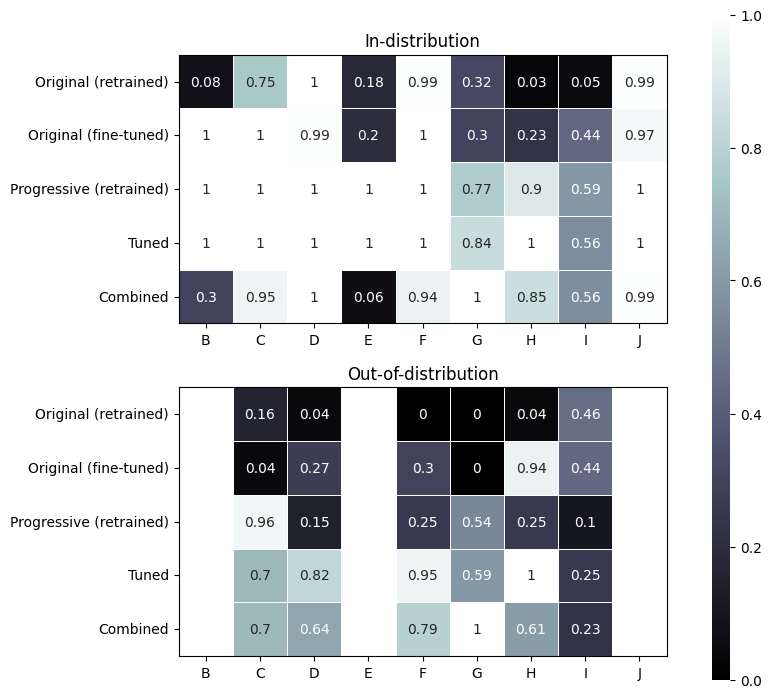

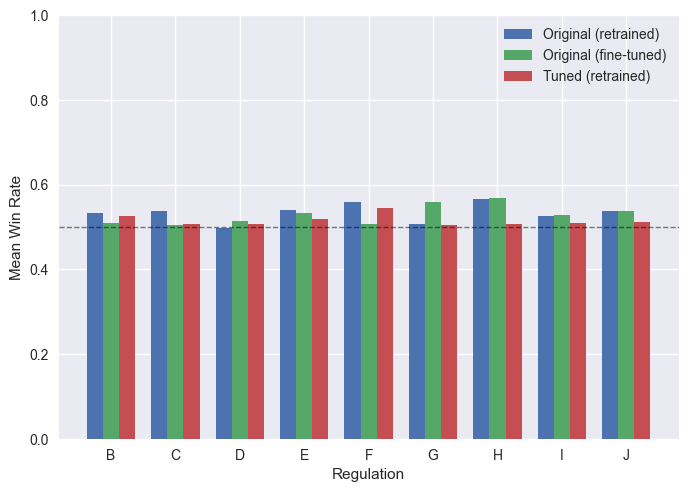

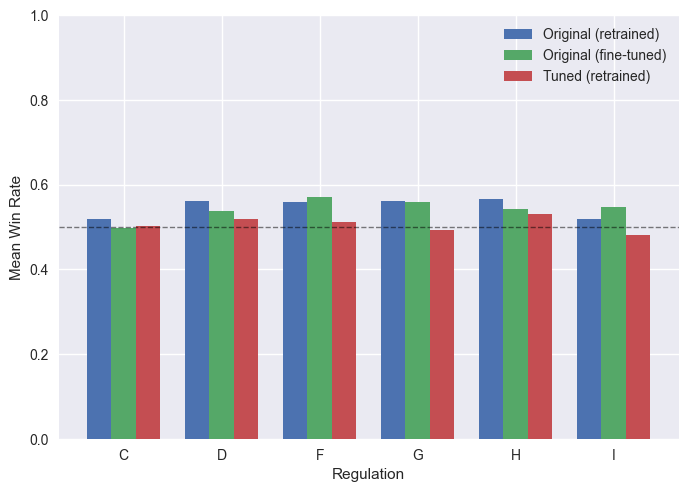

C:\Users\Thoma\AppData\Local\Temp\ipykernel_5184\1295145815.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(pad=2.5)


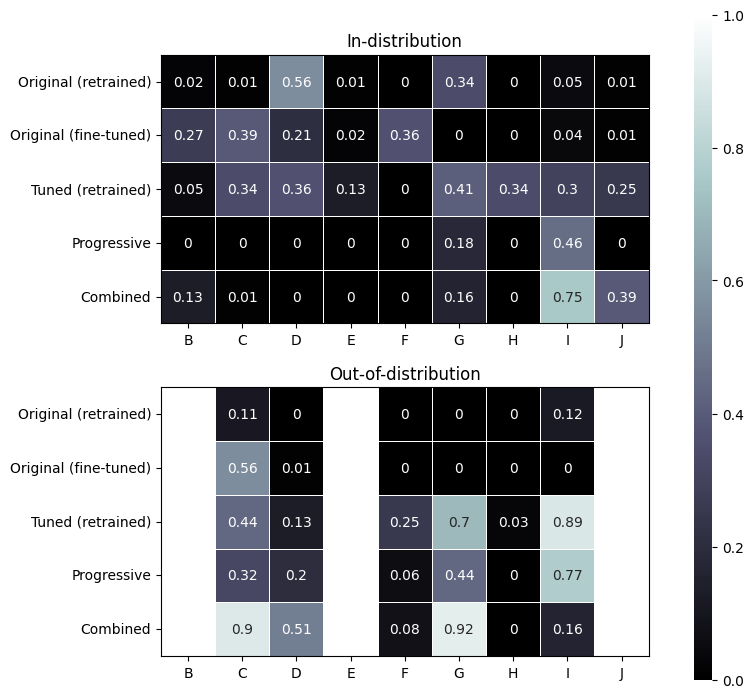

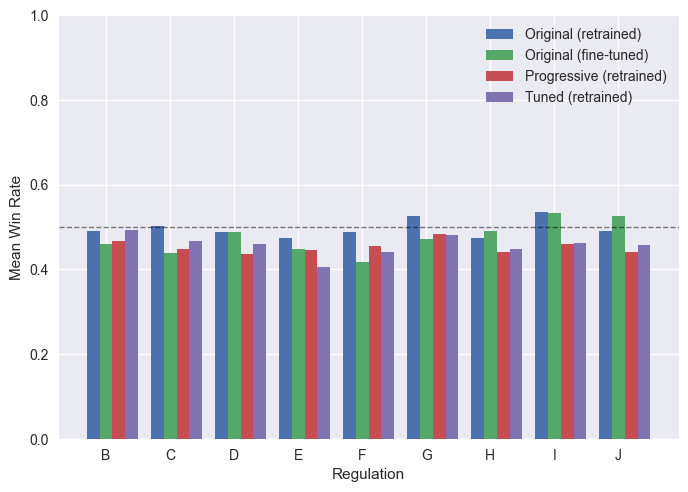

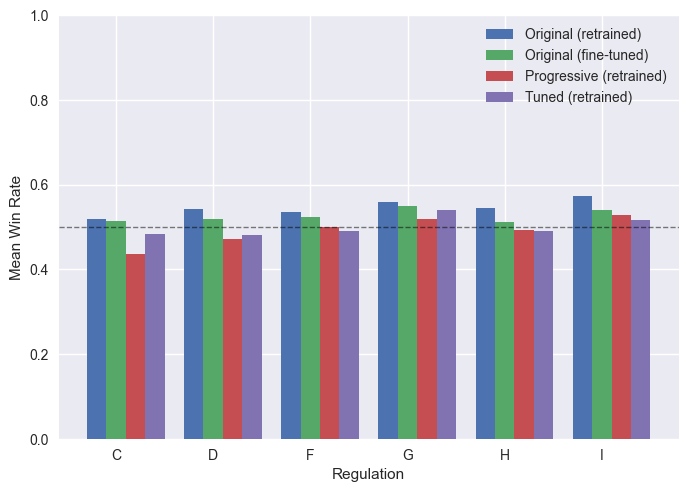

C:\Users\Thoma\AppData\Local\Temp\ipykernel_5184\1295145815.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(pad=2.5)


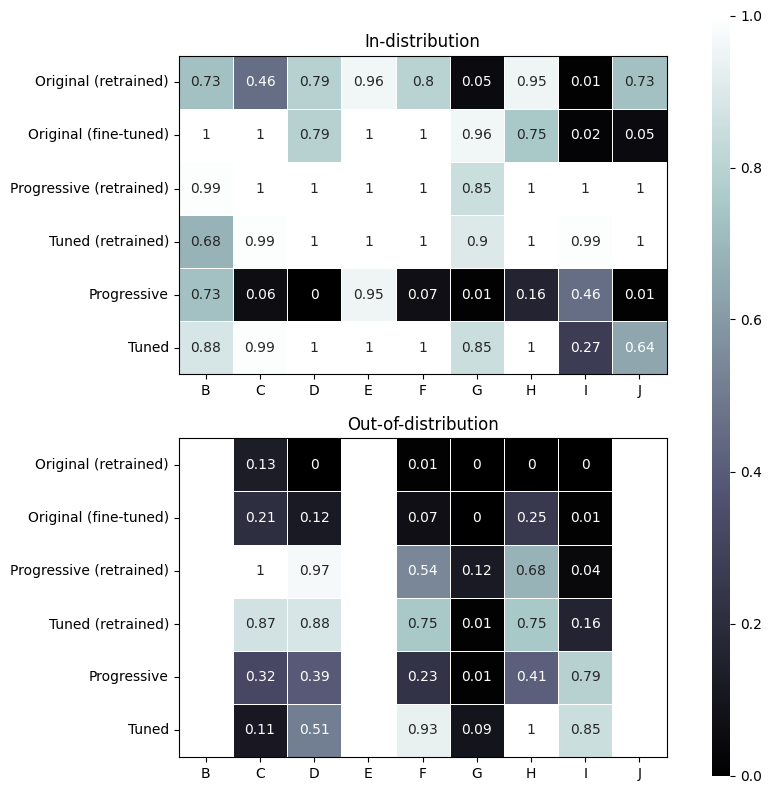

In [69]:
def plot_figures(model: str, labels: list[str]):
    if model == "progressive":
        data_in = progressive_in
        data_out = progressive_out
        idx = [(0,1),(0,2)]
    elif model == "tuned":
        data_in = tuned_in
        data_out = tuned_out
        idx = [(1,0),(1,2)]
    else:
        data_in = combined_in
        data_out = combined_out
        idx = [(2,0),(2,1)]
    width = 0.25 if len(labels) == 3 else 0.2

    def plot_bars(data: np.ndarray, in_dist: bool):
        regs = regs_in if in_dist else regs_out
        bars = [np.arange(len(regs))]
        for i in range(len(labels)-1):
            bars.append([x + width for x in bars[-1]]) # type: ignore
        for i in range(len(labels)):
            plt.bar(bars[i], data[i], width=width, label=labels[i])
        plt.axhline(y=0.5, linestyle='--', linewidth=1.0, color=(0, 0, 0, 0.5))
        plt.ylim(0, 1)
        plt.xlabel("Regulation")
        plt.ylabel("Mean Win Rate")
        plt.xticks([r + width for r in range(len(regs))], regs)
        plt.legend()
        plt.show()

    plt.style.use('seaborn-v0_8')
    plot_bars(data_in, True)
    plot_bars(data_out, False)

    # calculate p-values
    pvalues_in = np.zeros((data_in.shape[0]+2, data_in.shape[1]))
    pvalues_out = np.zeros((data_in.shape[0]+2, data_in.shape[1]))
    for i in range(len(labels)):
        j2 = 0
        for j in range(len(regs_in)):
            both = regs_in[j] in regs_out
            pvalues_in[i,j] = binomtest(int(data_in[i,j]*1000), 1000, 0.5, "greater").pvalue
            pvalues_out[i,j] = binomtest(int(data_out[i,j2]*1000), 1000, 0.5, "greater").pvalue if both else np.nan
            j2 += 1 if both else 0
    for i in range(2):
        j2 = 0
        for j in range(len(regs_in)):
            both = regs_in[j] in regs_out
            pvalues_in[len(labels)+i,j] = binomtest(int(playoff_in[j][*idx[i]]*1000), 1000, 0.5, "greater").pvalue
            pvalues_out[len(labels)+i,j] = binomtest(int(playoff_out[j2][*idx[i]]*1000), 1000, 0.5, "greater").pvalue if both else np.nan
            j2 += 1 if both else 0

    plt.style.use('default')
    fig, axs = plt.subplots(2, 1, figsize=(6, 7 if len(labels) == 3 else 8))
    cbar_ax = fig.add_axes((1, .05, .03, .95))
    fig.tight_layout(pad=2.5)

    sns.heatmap(
        pvalues_in.round(2),
        vmin=0,
        vmax=1,
        annot=True,
        cmap="bone",
        linewidth=0.5,
        xticklabels=regs_in,
        yticklabels=labels + [l for l in playoff_labels if l.lower() != model],
        ax=axs[0],
        cbar_ax=cbar_ax
    )
    axs[0].set_title("In-distribution")
    for _, spine in axs[0].spines.items():
        spine.set_visible(True) # borders around heatmap
    sns.heatmap(
        pvalues_out.round(2),
        vmin=0,
        vmax=1,
        annot=True,
        cmap="bone",
        linewidth=0.5,
        xticklabels=regs_in,
        yticklabels=labels + [l for l in playoff_labels if l.lower() != model],
        ax=axs[1],
        cbar_ax=cbar_ax
    )
    axs[1].set_title("Out-of-distribution")
    for _, spine in axs[1].spines.items():
        spine.set_visible(True) # borders around heatmap
    plt.show()

plot_figures("progressive", progressive_labels)
plot_figures("tuned", tuned_labels)
plot_figures("combined", combined_labels)

C:\Users\Thoma\AppData\Local\Temp\ipykernel_5184\3124174116.py:21: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(pad=1.5)


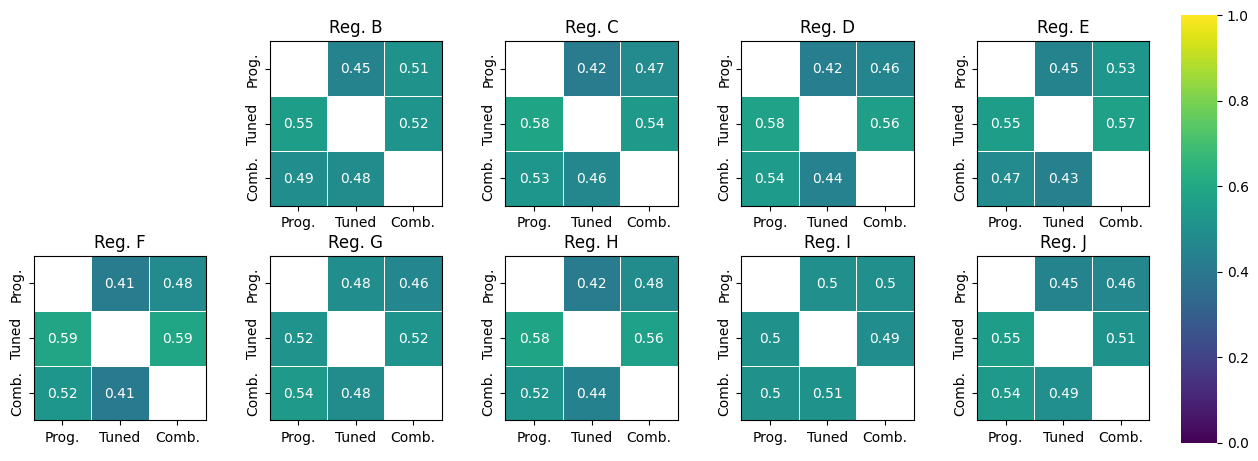

C:\Users\Thoma\AppData\Local\Temp\ipykernel_5184\3124174116.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(pad=1.5)


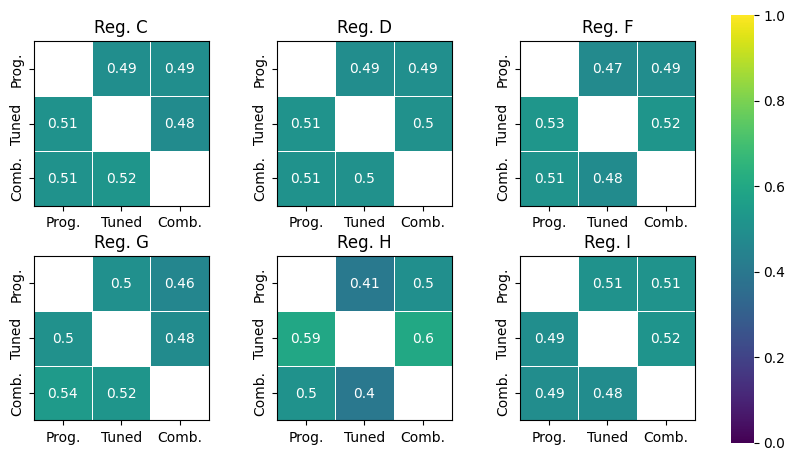

In [55]:
def heatmap(reg: int, ax: Axes, cbar_ax: Axes | None = None, out_of_dist: bool = False):
    sns.heatmap(
        playoff_in[reg] if (not out_of_dist) else playoff_out[reg],
        vmin=0,
        vmax=1,
        annot=True,
        cmap="viridis",
        linewidth=0.5,
        xticklabels=[l if len(l) <= 5 else l[:4]+"." for l in playoff_labels],
        yticklabels=[l if len(l) <= 5 else l[:4]+"." for l in playoff_labels],
        ax=ax,
        cbar_ax=cbar_ax
    )
    ax.set_title(f"Reg. {(regs_in if (not out_of_dist) else regs_out)[reg].upper()}")
    for _, spine in ax.spines.items():
        spine.set_visible(True) # borders around heatmap

eps = 1e-5
fig, axs = plt.subplots(2, 5, figsize=(12, 4.5))
cbar_ax = fig.add_axes((1, .05, .03, .95))
fig.tight_layout(pad=1.5)
axs[0,0].axis('off') # gap for reg A
for i in range(len(regs_in)):
    heatmap(i, axs[round((i + 1 - eps) / 8), (i + 1) % 5], cbar_ax)
plt.show()

fig, axs = plt.subplots(2, 3, figsize=(7.5, 4.5))
cbar_ax = fig.add_axes((1, .05, .03, .95))
fig.tight_layout(pad=1.5)
for i in range(len(regs_out)):
    heatmap(i, axs[round((i + eps) / 6), i % 3], cbar_ax, True)
plt.show()